# Reading TIFFs to CUDA memory

## Overview

In this tutorial, you learn:

* How to read a GeoTIFF into an xarray.DataArray backed by CuPy arrays
* Understand some of the limitations of the `cog3pio` engine

## Prerequisites

You will need to have a CUDA-enabled GPU (Volta generation or newer), and be running
on Linux, either x86_64 or aarch64 platform. Please ensure that you have installed
`cupy-xarray` with the 'tiff' extras that contains the `cog3pio` dependency, e.g. via

```bash
pip install cupy-xarray[tiff]
```

or if you are using conda, manually install `cog3pio` via

```bash
conda install -c conda-forge cog3pio cupy-xarray
```

There may be other system prerequisities needed by the underlying nvTIFF library used
by `cog3pio`, which you can check at
<https://docs.nvidia.com/cuda/nvtiff/index.html#prerequisites>

## Introduction

In this tutorial, we will learn how to read data stored in a GeoTIFF format into CUDA
GPU memory. This will use the [`cog3pio`](https://cog3pio.readthedocs.io) Python/Rust
library that contains bindings to
[nvTIFF](https://docs.nvidia.com/cuda/nvtiff/index.html) which does GPU-accelerated
decoding of TIFF (Tagged Image File Format) files.

Let's now import our packages

In [1]:
import cupy as cp
import xarray as xr

Check that the [Cog3pioBackendEntrypoint](../api.rst#module-cupy_xarray.cog3pio)
engine is available:

In [2]:
xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'cog3pio': <Cog3pioBackendEntrypoint>
   Use .tif files in Xarray
   Learn more at https://cog3pio.readthedocs.io/en/latest/,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html}

## Reading a single RGB GeoTIFF

We'll first read this
[EOX cloudless mosaic](https://source.coop/pangeo/example-tiff/geotiff-test-data/real_data/eox/eox_cloudless.tif)
(low-resolution version) GeoTIFF file with 3 bands (Red, Green, Blue), compressed
using Deflate. Use
[`xarray.open_dataarray()`](https://docs.xarray.dev/en/stable/generated/xarray.open_dataarray.html),
passing in the HTTP URL to the .tif file, configure `engine="cog3pio"` (shorthand for
`engine=Cog3pioBackendEntrypoint`) and set the `device_id` parameter to `0` to read
into CUDA GPU 0.

In [3]:
# Read GeoTIFF into an xarray.DataArray
dataarray: xr.DataArray = xr.open_dataarray(
    filename_or_obj="https://data.source.coop/pangeo/example-tiff/geotiff-test-data/real_data/eox/eox_cloudless.tif",
    engine="cog3pio",
    device_id=0,  # cuda:0
)
dataarray

<xarray.DataArray 'raster' (band: 3, y: 256, x: 512)> Size: 393kB
array([[[0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0],
        ...,
        [0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0]],

       [[0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0],
        ...,
        [0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0]],

       [[0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0],
        ...,
        [0, 0, ..., 0, 0],
        [0, 0, ..., 0, 0]]], shape=(3, 256, 512), dtype=uint8)
Coordinates:
  * band     (band) uint8 3B 0 1 2
  * y        (y) float64 2kB 89.65 88.95 88.24 87.54 ... -88.24 -88.95 -89.65
  * x        (x) float64 4kB -179.6 -178.9 -178.2 -177.5 ... 178.2 178.9 179.6

In [4]:
isinstance(dataarray.data, cp.ndarray)

True

That was quick and easy wasn't it? You now have an `xarray.DataArray` with dimensions
channels/band: 0, height/y: 2355, and width/x: 2325 in CUDA GPU memory!

We can plot this RGB image by calling
[`.plot.imshow()`](https://docs.xarray.dev/en/stable/generated/xarray.plot.imshow.html)
on the `xarray.DataArray`.

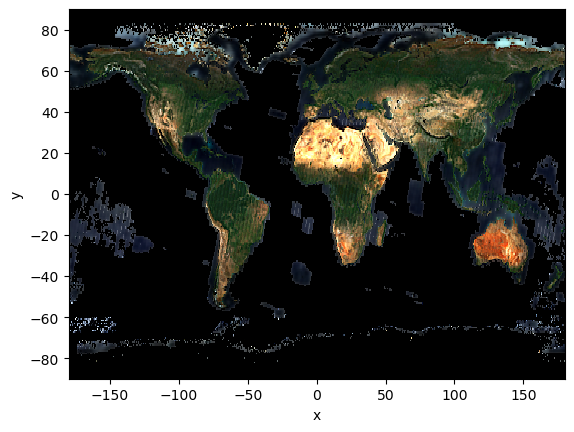

In [5]:
dataarray.plot.imshow()

Notice that most of the ocean areas are coloured black (pixel value 0) instead of
with a transparent colour. This is because `cog3pio=0.1.0` doesn't have the ability to
deal with NaN values yet, so you will need to manually handle this.